# Intervaller: hva modellene ikke vet

Arbeidsverk 2, notebook 05. Bygger på notebook 02 (det tidsgyldige konformale
skjemaet), 03 og 04 (punktmodellene).

Alle modellene i notebook 03 og 04 gir ett tall per måned. Modellstigen i arbeidsverk
1 er skåret på dekning og intervallskår i tillegg til MASE, og på de to kolonnene har
arbeidsverk 2 hittil ikke kunnet stille opp i det hele tatt. For en etat som
dimensjonerer kapasitet er det intervallet som er beslutningsgrunnlaget: hvor mange
plasser må finnes hvis det går verre enn ventet.

Notebook 02 bygget verktøyet — konformale intervaller kalibrert bare på prognosefeil
som faktisk var realisert ved opprinnelsen — og målte samtidig svakheten: ved tolv
måneders horisont finnes bare 19 kalibreringspunkter. Denne notebooken bruker
verktøyet og prøver å reparere svakheten med bydelspanelet.


## 1. Oppsett


In [1]:
import os, subprocess, sys

def git(*a, standard=None):
    try:
        return subprocess.run(["git", *a], capture_output=True, text=True,
                              check=True, cwd=REPO).stdout.strip()
    except Exception:
        return standard

REPO = "/content/bostotte-oslo" if os.path.isdir("/content/bostotte-oslo") else "."
if not os.path.isdir(os.path.join(REPO, "data")):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/Torcode/bostotte-oslo.git",
                    "/content/bostotte-oslo"], check=True)
    REPO = "/content/bostotte-oslo"
elif REPO.startswith("/content"):
    git("fetch", "--depth", "1", "origin", "main"); git("reset", "--hard", "origin/main")

for pakke in ["torch", "xgboost"]:
    try: __import__(pakke)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pakke], check=True)

COMMIT, UTTREKK = git("rev-parse", "--short", "HEAD", standard="ukjent"), "2026-08-04"
print("repo    :", os.path.abspath(REPO))
print("commit  :", COMMIT)
print("uttrekk :", UTTREKK)


repo    : /home/claude/bostotte-oslo
commit  : dde7cd9
uttrekk : 2026-08-04


In [2]:
# harmoni-med-git: denne cellen holdes utenfor sitt eget avtrykk
KILDEAVTRYKK = "2b571403f62565a086cc54a2b10221f952b08ca949e0b16e97a6c77e4bccefe1"
FIL_MEG = "bostotte_05_intervaller.ipynb"
RAATT = f"https://raw.githubusercontent.com/Torcode/bostotte-oslo/main/notebooks/{FIL_MEG}"
LOGG  = ("https://api.github.com/repos/Torcode/bostotte-oslo/commits"
         f"?path=notebooks/{FIL_MEG}&per_page=1")

import hashlib, json
import urllib.request, urllib.error

def kildeavtrykk(celler):
    ut = []
    for c in celler:
        kilde = c["source"] if isinstance(c["source"], str) else "".join(c["source"])
        if "harmoni-med-git" not in kilde:
            ut.append(kilde)
    return hashlib.sha256("\n".join(ut).encode("utf-8")).hexdigest()

def hent(url, sekunder=40):
    with urllib.request.urlopen(url, timeout=sekunder) as r:
        return json.load(r)

try:    NAAR = " (sist endret " + hent(LOGG)[0]["commit"]["committer"]["date"][:10] + ")"
except Exception: NAAR = ""
try:
    paa_main = kildeavtrykk(hent(RAATT)["cells"])
    MANIFEST_HARMONI = "i harmoni" if paa_main == KILDEAVTRYKK else "avvik mot main"
    print(f"I harmoni med main{NAAR}." if paa_main == KILDEAVTRYKK else
          f"AVVIK mot main. denne {KILDEAVTRYKK[:16]}..., main {paa_main[:16]}...{NAAR}")
except urllib.error.HTTPError as e:
    MANIFEST_HARMONI = "finnes ikke paa main" if e.code == 404 else f"HTTP {e.code}"
    print("Notebooken ligger ikke paa main ennaa." if e.code == 404
          else f"Kontrollen fikk HTTP {e.code}.")
except Exception as e:
    MANIFEST_HARMONI = f"ikke sjekket ({type(e).__name__})"
    print(f"Kontrollen naadde ikke GitHub ({type(e).__name__}).")


I harmoni med main.


## 2. Forhåndsregistreringen, med tidsstempel

Notebook 03 og 04 hadde forhåndsregistreringen i selve notebooken. Det er svakt:
filen kan ikke bevise at påstandene ble skrevet før tallene forelå. Notebook 04 lovet
at det skulle rettes fra og med denne notebooken.

Forhåndsregistreringen ligger derfor i `notebooks/forhandsregistrering_05.md`, i en
egen commit gjort før noen modell her var kjørt. Cellen under henter den fra `main`
og skriver ut når den ble committet. Det gjør rekkefølgen etterprøvbar framfor
påstått.


In [3]:
FR_STI = "notebooks/forhandsregistrering_05.md"
FR_RAATT = f"https://raw.githubusercontent.com/Torcode/bostotte-oslo/main/{FR_STI}"
FR_LOGG = ("https://api.github.com/repos/Torcode/bostotte-oslo/commits"
           f"?path={FR_STI}&per_page=1")

# Eksistensen hentes fra raw, datoen fra API-et. De to kan feile hver for seg.
try:
    with urllib.request.urlopen(FR_RAATT, timeout=40) as r:
        FR_TEKST = r.read().decode("utf-8")
    FR_SHA = hashlib.sha256(FR_TEKST.encode("utf-8")).hexdigest()
    print(f"Forhaandsregistreringen ligger paa main: {len(FR_TEKST)} tegn, "
          f"sha256 {FR_SHA[:16]}...")
    print(f"  foerste linje: {FR_TEKST.splitlines()[0]}")
except Exception as e:
    FR_SHA = f"ikke hentet ({type(e).__name__})"
    print(f"Naadde ikke forhaandsregistreringen paa main ({type(e).__name__}).")

try:
    fr = hent(FR_LOGG)
    FR_COMMIT, FR_DATO = fr[0]["sha"][:7], fr[0]["commit"]["committer"]["date"]
    print(f"  committet {FR_DATO} som {FR_COMMIT}: "
          f"{fr[0]['commit']['message'].splitlines()[0]}")
except Exception as e:
    FR_COMMIT, FR_DATO = "ukjent", "ukjent"
    print(f"  commit-datoen krever GitHubs API, som ikke svarte "
          f"({type(e).__name__}). Den staar i git-historikken uansett.")


Forhaandsregistreringen ligger paa main: 3694 tegn, sha256 da368ef553a06b67...
  foerste linje: # Forhåndsregistrering, notebook 05: intervaller
  commit-datoen krever GitHubs API, som ikke svarte (HTTPError). Den staar i git-historikken uansett.


De fire påstandene, gjengitt her for lesbarhet. Ordlyden i filen på `main` er den som
gjelder.

**P1** — Det tidsgyldige konformale skjemaet underdekker, mest på lange horisonter.
*Felles hvis samlet dekning lander innenfor to prosentpoeng av 80, eller hvis
underdekningen ikke er større ved h = 12 enn ved h = 1.*

**P2** — Kalibrering på bydelspanelet hjelper. *Felles hvis panelkalibrering ikke
bedrer dekningen ved h = 12.*

**P3** — Ukorrigert panelkalibrering overdekker, fordi bydelenes prognosefeil på
logskala er større enn Oslos. *Felles hvis ukorrigert panelkalibrering ikke gir
høyere dekning enn korrigert.*

**P4** — Beste punktmodell er ikke automatisk best på intervallskår. *Felles hvis
rangeringen på intervallskår er den samme som rangeringen på MASE.*


In [4]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import platform, importlib, time
import torch, torch.nn as nn
from xgboost import XGBRegressor
torch.set_num_threads(max(1, os.cpu_count() or 2))

RAW = os.path.join(REPO, "data/raw/")
FIL = "husbanken_bostotte_oslo_manedlig.csv"

def sha256(sti, blokk=1 << 20):
    h = hashlib.sha256()
    with open(sti, "rb") as f:
        for b in iter(lambda: f.read(blokk), b""):
            h.update(b)
    return h.hexdigest()

SJEKKSUM = sha256(RAW + FIL)
NB04 = ("https://raw.githubusercontent.com/Torcode/bostotte-oslo/"
        "main/notebooks/bostotte_04_kapasitet.ipynb")

def manifest_fra_notebook(url, noekkel):
    nb = hent(url, 60)
    for celle in reversed(nb["cells"]):
        if celle["cell_type"] == "code" and noekkel in "".join(celle["source"]):
            for u in celle.get("outputs", []):
                if u.get("output_type") == "stream":
                    return json.loads("".join(u["text"]))
    raise LookupError("fant ikke manifestet")

try:
    M04 = manifest_fra_notebook(NB04, 'MANIFEST["kapasitet"]')
    assert M04["sjekksum"][FIL] == SJEKKSUM and M04["uttrekk"] == UTTREKK
    LENKE = "samme uttrekk og samme fil"
    L0_NB04 = M04["kapasitet"]["L0"]["MASE"]
    print(f"Notebook 04 paa main, samme uttrekk. L0 der: MASE {L0_NB04}.")
except Exception as e:
    LENKE, L0_NB04 = f"ikke sjekket ({type(e).__name__})", None
    print(f"Naadde ikke notebook 04 paa main ({type(e).__name__}).")

SEED = 20260807
np.random.seed(SEED)
pd.set_option("display.width", 130); pd.set_option("display.max_columns", 30)
SERIE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLEKK, BLEKK_2, DEMPET = "#0b0b0b", "#52514e", "#898781"
RUTE, BASIS = "#e1e0d9", "#c3c2b7"
HARDT = chr(160)
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130, "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.size": 8.5, "axes.titlesize": 9.5, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "text.color": BLEKK, "axes.labelcolor": BLEKK_2,
    "xtick.color": DEMPET, "ytick.color": DEMPET,
    "xtick.labelcolor": BLEKK_2, "ytick.labelcolor": BLEKK_2,
    "axes.edgecolor": BASIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": RUTE, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 7.5,
    "lines.linewidth": 1.6, "lines.solid_capstyle": "round"})

def tusen(v, _=None):
    return f"{v:,.0f}".replace(",", HARDT)

MANIFEST = {"commit": COMMIT, "uttrekk": UTTREKK, "python": platform.python_version(),
            "pakker": {}, "sjekksum": {FIL: SJEKKSUM}, "seed": SEED,
            "lenke_notebook04": LENKE,
            "forhaandsregistrering": {"commit": FR_COMMIT, "dato": FR_DATO,
                                      "sha256_fil": FR_SHA}}
for p in ["numpy", "pandas", "torch", "xgboost", "matplotlib"]:
    try:    MANIFEST["pakker"][p] = importlib.import_module(p).__version__
    except ImportError: MANIFEST["pakker"][p] = None
print("pakker:", MANIFEST["pakker"])


Notebook 04 paa main, samme uttrekk. L0 der: MASE 0.767.
pakker: {'numpy': '2.4.4', 'pandas': '3.0.2', 'torch': '2.13.0+cpu', 'xgboost': '3.2.0', 'matplotlib': '3.10.9'}


## 3. Protokollen, kontrollert for fjerde gang


In [5]:
raa = pd.read_csv(RAW + FIL)
raa["dato"] = pd.to_datetime(dict(year=raa.aar, month=raa.manedsnr, day=1))
raa = raa.sort_values("dato").reset_index(drop=True)
kant = raa.index[(raa.dato == raa.dato.max()) & (raa.ant_husstander_termin == 0)]
est = raa.drop(index=kant); est = est[est.dato >= "2017-01-01"].reset_index(drop=True)
M, N_EST = est.set_index("dato")["ant_husstander_termin"].astype(float), len(est)
LOG_M = np.log(M)
MIN_TRENING, H_MAKS = 72, 12
OPPRINNELSER = [est.dato.iloc[i-1] for i in range(1, N_EST+1)
                if MIN_TRENING <= i <= N_EST - H_MAKS]
NEVNER = {t0: np.abs(M.loc[:t0].values[12:] - M.loc[:t0].values[:-12]).mean()
          for t0 in OPPRINNELSER}
Z80, ALFA = 1.2815515655446004, 0.20
assert (len(OPPRINNELSER), N_EST) == (31, 114)

def maal(D, kol="mu"):
    e = D.sant - np.exp(D[kol])
    return pd.Series({"MASE": (e.abs()/D.q).mean(), "RMSE": np.sqrt((e**2).mean())})

kon = []
for t0 in OPPRINNELSER:
    tr = LOG_M.loc[:t0]
    sd0 = np.sqrt((np.diff(tr.values)**2).mean())
    for h in range(1, H_MAKS+1):
        m_ = t0 + pd.DateOffset(months=h)
        kon.append(dict(opprinnelse=t0, h=h, sant=M.loc[m_], q=NEVNER[t0],
                        mu=tr.iloc[-1], sd=sd0*np.sqrt(h)))
KON = pd.DataFrame(kon)
assert [round(float(maal(KON)["MASE"]), 3), round(float(maal(KON)["RMSE"]))] == [1.003, 1698]
NAIV = float(maal(KON)["MASE"])
print(f"Protokollen gir M0 MASE {NAIV:.3f}, RMSE {maal(KON)['RMSE']:.0f}, som i arbeidsverk 1.")


Protokollen gir M0 MASE 1.003, RMSE 1698, som i arbeidsverk 1.


## 4. Prognosefeil for hele hierarkiet

Konformal kalibrering trenger prognosefeil, ikke modeller. Én global tilpasning per
kombinasjon av opprinnelse og horisont gir prognoser for alle seksten seriene på én
gang, og dermed seksten ganger så mange feil som Oslo alene har.

Rekkefølgen seriene stables i er skrevet ned og navngitt i koden. Det er ikke
pedanteri; avsnitt 5 viser hvorfor.


In [6]:
mnd_alle = pd.date_range("2010-01-01", "2027-12-01", freq="MS")
X = pd.DataFrame(index=mnd_alle)
X["win_covid"] = ((mnd_alle >= "2020-04-01") & (mnd_alle <= "2020-10-01")).astype(int)
X["win_strom"] = ((mnd_alle >= "2021-12-01") & (mnd_alle <= "2024-03-01")).astype(int)
X["pakke_2024h2"] = (((mnd_alle >= "2024-07-01").astype(int)
                      + (mnd_alle >= "2024-09-01").astype(int)
                      + (mnd_alle >= "2024-10-01").astype(int)) / 3)

def u_av_fase(fase=0, fra=pd.Timestamp("2010-01-01"), til=pd.Timestamp("2027-12-31")):
    anker = pd.Timestamp("2014-01-06") + pd.Timedelta(days=fase)
    start = anker - pd.Timedelta(days=14*int(np.ceil((anker - fra).days/14)))
    d = pd.date_range(start, til, freq="14D"); d = d[d >= fra]
    return pd.Series(d).dt.to_period("M").dt.to_timestamp().value_counts().sort_index()

u = u_av_fase().reindex(mnd_alle)
X["k_pre"]  = (u - 26/12) * (mnd_alle <= "2024-12-01").astype(int)
X["k_post"] = (u - 26/12) * (mnd_alle >= "2025-01-01").astype(int)
REG, MIN_NZ, LAG = list(X.columns), 6, [1, 2, 3, 6, 11, 12]

def trekk(serie, s):
    v = serie.loc[:s]
    if len(v) < 13: return None
    d = np.diff(np.log(v.values))
    ut = {f"lag{l}": np.log(v.iloc[-1-l]) - np.log(v.iloc[-1]) for l in LAG}
    ut["niva"] = np.log(v.iloc[-1]); ut["d1"] = d[-1]
    ut["d12"] = np.log(v.iloc[-1]) - np.log(v.iloc[-13])
    ut["sd6"] = d[-6:].std(); ut["sd12"] = d[-12:].std(); ut["snitt6"] = d[-6:].mean()
    return ut

def historikk(serie):
    r = {s: trekk(serie, s) for s in serie.index}
    return pd.DataFrame({s: v for s, v in r.items() if v is not None}).T

byd = pd.read_csv(RAW + "husbanken_bostotte_oslo_bydel_manedlig.csv",
                  dtype={"kommunenr": str})
byd["dato"] = pd.to_datetime(dict(year=byd.aar, month=byd.manedsnr, day=1))
byd = byd[byd.ant_husstander_termin > 0]
PANEL = {k: g.set_index("dato")["ant_husstander_termin"].astype(float).sort_index()
         for k, g in byd.groupby("kommunenr") if k != "0301"}
PANEL = {k: v[v.index >= "2017-01-01"] for k, v in PANEL.items()}
SERIER = {"OSLO": M, **PANEL}
REKKE = ["OSLO"] + sorted(PANEL)      # fast rekkefoelge: Oslo, deretter kommunenummer
HIST = {k: historikk(v) for k, v in SERIER.items()}
KOL = list(HIST["OSLO"].columns) + ["mnd"] + REG
STORRELSE = {k: float(SERIER[k].loc[:"2022-12"].mean()) for k in REKKE}

def sett(navn, t0, h, aktive):
    s, hh = SERIER[navn], HIST[navn]
    kilder = hh.index[hh.index + pd.DateOffset(months=h) <= t0]
    kilder = kilder[[k + pd.DateOffset(months=h) in s.index for k in kilder]]
    if len(kilder) == 0: return None, None
    maalmnd = kilder + pd.DateOffset(months=h)
    D = hh.loc[kilder].copy(); D["mnd"] = maalmnd.month
    for r in REG: D[r] = X.loc[maalmnd, r].values if r in aktive else 0.0
    y = np.log(s.loc[maalmnd].values) - np.log(s.loc[kilder].values)
    return D[KOL].to_numpy(dtype=float), y

def prediksjonsrad(navn, t0, h, aktive):
    m_ = t0 + pd.DateOffset(months=h)
    if t0 not in HIST[navn].index or m_ not in SERIER[navn].index: return None
    d = HIST[navn].loc[[t0]].copy(); d["mnd"] = m_.month
    for r in REG: d[r] = X.loc[m_, r] if r in aktive else 0.0
    return d[KOL].to_numpy(dtype=float)

EPOKER, LR, WD = 400, 1e-2, 1e-4
PARAM = dict(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
             colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
             random_state=SEED, n_jobs=4, verbosity=0)

def lineaer(Xg, yg, Xpr):
    mx, sx = Xg.mean(0), Xg.std(0) + 1e-9
    my, sy = yg.mean(), yg.std() + 1e-9
    Xn = torch.tensor((Xg - mx)/sx, dtype=torch.float32)
    yn = torch.tensor((yg - my)/sy, dtype=torch.float32).view(-1, 1)
    Pn = torch.tensor((Xpr - mx)/sx, dtype=torch.float32)
    torch.manual_seed(SEED)
    m = nn.Linear(Xn.shape[1], 1)
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=WD); f = nn.MSELoss()
    for _ in range(EPOKER):
        opt.zero_grad(); l = f(m(Xn), yn); l.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        return m(Pn).numpy().ravel()*sy + my

def kjor(rekke):
    rader = []
    for t0 in OPPRINNELSER:
        aktive = [r for r in REG if (X.loc[M.loc[:t0].index, r] != 0).sum() >= MIN_NZ]
        for h in range(1, H_MAKS + 1):
            Xs, ys = [], []
            for navn in rekke:
                a, b = sett(navn, t0, h, aktive)
                if a is not None: Xs.append(a); ys.append(b)
            Xg, yg = np.vstack(Xs), np.concatenate(ys)
            navn_pr, Xpr = [], []
            for navn in rekke:
                p = prediksjonsrad(navn, t0, h, aktive)
                if p is not None: navn_pr.append(navn); Xpr.append(p)
            Xpr = np.vstack(Xpr)
            v_L0 = lineaer(Xg, yg, Xpr)
            v_G2 = XGBRegressor(**PARAM).fit(Xg, yg).predict(Xpr)
            m_ = t0 + pd.DateOffset(months=h)
            for i, navn in enumerate(navn_pr):
                ank = np.log(SERIER[navn].loc[t0])
                rader.append(dict(serie=navn, opprinnelse=t0, h=h, dato=m_,
                                  sant=float(SERIER[navn].loc[m_]),
                                  storrelse=STORRELSE[navn],
                                  L0=ank + float(v_L0[i]), G2=ank + float(v_G2[i]),
                                  M0=ank))
    return pd.DataFrame(rader)

t = time.time()
R = kjor(REKKE)
for m in ["L0", "G2", "M0"]:
    R["lf_" + m] = np.log(R.sant) - R[m]
O = R[R.serie == "OSLO"].copy()
O["q"] = O.opprinnelse.map(NEVNER)
print(f"{len(R)} rader, {R.serie.nunique()} serier, {time.time()-t:.0f} s\n")
punkt = pd.DataFrame({m: maal(O, m) for m in ["M0", "G2", "L0"]}).T.round(
    {"MASE": 3, "RMSE": 0})
punkt["fasit"] = ["1,003 / 1 698 (arbeidsverk 1)", "0,815 / 1 408 (notebook 03)",
                  f"{L0_NB04} / 1 308 (notebook 04)" if L0_NB04 else "notebook 04"]
punkt


5952 rader, 16 serier, 119 s



,MASE,RMSE,fasit
M0,1.003,1698.0,"1,003 / 1 698 (arbeidsverk 1)"
G2,0.815,1408.0,"0,815 / 1 408 (notebook 03)"
L0,0.767,1308.0,0.767 / 1 308 (notebook 04)


Alle tre punktmodellene reproduserer tallene fra notebookene de kommer fra. Det er
fjerde gang protokollen kontrolleres, og første gang de trebaserte og de lineære
prognosene regnes i samme kjøring.


## 5. En modell som avhenger av radrekkefølgen

Under arbeidet med denne notebooken kom gradientboosting først ut på MASE 0,823, mot
0,815 i notebook 03. Samme data, samme frø, samme hyperparametre.

Forskjellen var **rekkefølgen de seksten seriene ble stablet i**. Notebook 03 la dem
inn i kommunenummerrekkefølge; et tidlig utkast her sorterte dem etter størrelse.
`subsample = 0,8` trekker rader ved hvert tre, og trekningen følger radenes posisjon.
Cellen under kjører begge rekkefølgene.


In [7]:
REKKE_STOR = ["OSLO"] + sorted(PANEL, key=lambda k: -PANEL[k].iloc[-1])
t = time.time()
R2 = kjor(REKKE_STOR)
O2 = R2[R2.serie == "OSLO"].copy(); O2["q"] = O2.opprinnelse.map(NEVNER)

rekkefolge = pd.DataFrame({
    "kommunenummer": [maal(O, "G2")["MASE"], maal(O, "L0")["MASE"]],
    "storrelse":     [maal(O2, "G2")["MASE"], maal(O2, "L0")["MASE"]],
}, index=["G2 gradientboosting", "L0 lineaer"]).round(4)
rekkefolge["forskjell"] = (rekkefolge.storrelse - rekkefolge.kommunenummer).round(4)
rekkefolge.index.name = None
L0_DIFF = abs(float(maal(O, "L0")["MASE"] - maal(O2, "L0")["MASE"]))
print(f"{time.time()-t:.0f} s")
print(f"L0s forskjell mellom de to rekkefolgene: {L0_DIFF:.2e} i MASE\n")
rekkefolge


111 s
L0s forskjell mellom de to rekkefolgene: 6.23e-07 i MASE



,kommunenummer,storrelse,forskjell
G2 gradientboosting,0.8155,0.8229,0.0074
L0 lineaer,0.7671,0.7671,0.0000


Den trebaserte modellen flytter seg 0,0074 i MASE av en ren ombytting av rader. Den
lineære flytter seg i sjuende desimal — det som gjenstår der, er at flyttallsaddisjon
ikke er assosiativ, ikke at modellen er en annen. Grunnen er at den trenes med full
batch: gradienten er en sum over alle rader, og en sum bryr seg ikke om rekkefølgen.

Det er en fjerde sort feil ved siden av kalenderforvekslingen, konformallekkasjen og
det utrente nettet. Denne er den stilleste av dem alle: samme kode, samme data, samme
frø — og likevel to tall. **Radrekkefølgen er en del av spesifikasjonen når `subsample`
er under 1**, og den skal derfor stå navngitt i koden framfor å følge av hvilken
`groupby` som tilfeldigvis ble brukt.

Størrelsesordenen er verdt å måle mot noe: 0,007 er mindre enn avstanden mellom
gradientboosting og den lineære modellen (0,048), men større enn en tredjedel av den.
En sammenlikning mellom modellklasser på dette materialet tåler altså ikke å bli lest
på tredje desimal.

Resten av notebooken bruker kommunenummerrekkefølgen, som er den notebook 03 brukte.


## 6. P1: skjemaet fra notebook 02, på en bedre punktmodell

Det tidsgyldige skjemaet bygger intervallet av kvantilen til $|e_h|$ fra opprinnelser
der feilen faktisk var realisert, altså $t_j + h \le t_i$. Notebook 02 målte 67,4 %
dekning mot nominelle 80 for den naive modellen. Spørsmålet er om en bedre
punktmodell endrer det.


In [8]:
NIVA, MIN_KAL = 0.80, 3

def konformal(R, modell, kilde, min_kal=MIN_KAL):
    kol = "lf_" + modell
    ut = []
    for h, g in R.groupby("h"):
        realisert = g.opprinnelse + pd.DateOffset(months=int(h))
        oslo = g[g.serie == "OSLO"].sort_values("opprinnelse")
        for _, r in oslo.iterrows():
            ti = r.opprinnelse
            kal = g[(realisert <= ti).values]
            if kilde == "egen":
                kal = kal[kal.serie == "OSLO"]
            if len(kal) < min_kal:
                continue
            ut.append(dict(h=h, opprinnelse=ti, n_kal=len(kal),
                           q=np.quantile(kal[kol].abs().values, NIVA, method="linear"),
                           sant=r.sant, mu=r[modell]))
    return pd.DataFrame(ut)

def intervallmaal(D):
    l, u = np.exp(D.mu - D.q), np.exp(D.mu + D.q)
    dekk = (D.sant >= l) & (D.sant <= u)
    ws = (u - l) + (2/ALFA)*(l - D.sant)*(D.sant < l) + (2/ALFA)*(D.sant - u)*(D.sant > u)
    return pd.Series({"n": len(D), "dekning %": 100*dekk.mean(),
                      "intervallskaar": ws.mean(), "median bredde": np.median(u - l)})

EGEN = {m: konformal(R, m, "egen") for m in ["M0", "G2", "L0"]}
tab = pd.DataFrame({m: intervallmaal(D) for m, D in EGEN.items()}).T.round(
    {"n": 0, "dekning %": 1, "intervallskaar": 0, "median bredde": 0})
tab.index.name = None
print(f"Nominelt nivaa 80 %. Notebook 02 maalte 67,4 % for M0 med dette skjemaet.\n")
tab


Nominelt nivaa 80 %. Notebook 02 maalte 67,4 % for M0 med dette skjemaet.



,n,dekning %,intervallskaar,median bredde
M0,270.0,67.4,8072.0,3159.0
G2,270.0,65.9,6371.0,3007.0
L0,270.0,67.8,5558.0,2840.0


M0 gir 67,4 %, samme tall som notebook 02, som det skal. De to bedre punktmodellene
gir 65,9 og 67,8 — altså **ingen forbedring i dekning fra en bedre punktprognose.**
Det er som forventet: konformal kalibrering justerer bredden til feilene modellen
faktisk gjør, så en bedre modell får smalere intervaller, ikke riktigere dekning.
Bredden faller fra 3 159 til 2 840 husstander og intervallskåren fra 8 072 til 5 558.

Underdekningen på tolv til fjorten prosentpoeng er ikke tilfeldig støy. **P1 holdt**,
og figuren i avsnitt 7 viser at den er verst der forhåndsregistreringen sa den skulle
være.


## 7. P2: kalibrering på hele hierarkiet

Ved hver opprinnelse og horisont finnes nå seksten ganger så mange realiserte feil,
fordi bydelene prognostiseres av samme modell i samme kjøring. Spørsmålet er om de
kan brukes til å kalibrere Oslo.


In [9]:
PANELKAL = {m: konformal(R, m, "panel") for m in ["M0", "G2", "L0"]}

FELLES = set(map(tuple, EGEN["L0"][["h", "opprinnelse"]].values))
def paa_felles(D):
    return D[[tuple(x) in FELLES for x in D[["h", "opprinnelse"]].values]]

sml = []
for m in ["M0", "G2", "L0"]:
    for navn, D in [("egen historie", EGEN[m]), ("hele panelet", PANELKAL[m])]:
        s = intervallmaal(paa_felles(D))
        sml.append(dict(modell=m, kalibrering=navn, **s))
sml = pd.DataFrame(sml).set_index(["modell", "kalibrering"]).round(
    {"n": 0, "dekning %": 1, "intervallskaar": 0, "median bredde": 0})
print(f"Alt regnet paa de {len(FELLES)} punktene begge skjemaene skaarer.\n")
print(f"Kalibreringspunkter ved h = 12: "
      f"{EGEN['L0'].query('h == 12').n_kal.max()} med egen historie, "
      f"{PANELKAL['L0'].query('h == 12').n_kal.max()} med panelet.\n")
sml


Alt regnet paa de 270 punktene begge skjemaene skaarer.

Kalibreringspunkter ved h = 12: 19 med egen historie, 304 med panelet.



n  dekning %  intervallskaar  median bredde
modell kalibrering                                                   
M0     egen historie  270.0       67.4          8072.0         3159.0
       hele panelet   270.0       71.5          7613.0         3563.0
G2     egen historie  270.0       65.9          6371.0         3007.0
       hele panelet   270.0       71.5          6023.0         3342.0
L0     egen historie  270.0       67.8          5558.0         2840.0
       hele panelet   270.0       73.7          5302.0         3442.0

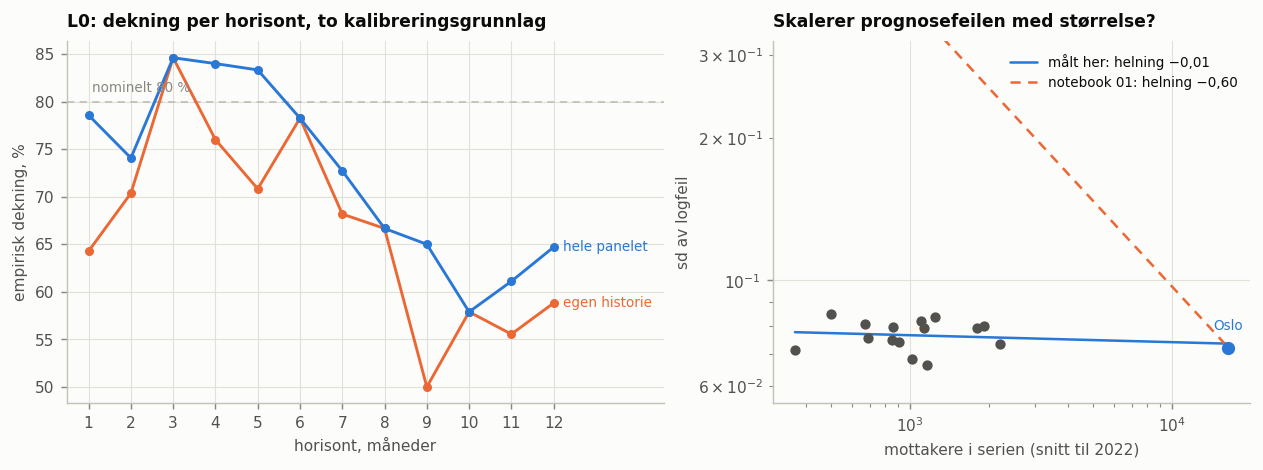

In [10]:
fig, akser = plt.subplots(1, 2, figsize=(9.6, 3.5), layout="constrained",
                          gridspec_kw={"width_ratios": [1.25, 1]})

def per_h(D):
    l, u = np.exp(D.mu - D.q), np.exp(D.mu + D.q)
    d = D.assign(dekk=(D.sant >= l) & (D.sant <= u))
    return 100*d.groupby("h").dekk.mean()

ax = akser[0]
for navn, D, farge in [("egen historie", paa_felles(EGEN["L0"]), SERIE[1]),
                       ("hele panelet", paa_felles(PANELKAL["L0"]), SERIE[0])]:
    p = per_h(D)
    ax.plot(p.index, p.values, color=farge, marker="o", ms=4)
    ax.annotate(navn, xy=(12, p.iloc[-1]), xytext=(5, 0), textcoords="offset points",
                ha="left", va="center", fontsize=7.5, color=farge, annotation_clip=False)
ax.axhline(80, color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.annotate("nominelt 80 %", xy=(1, 80), xytext=(2, 4), textcoords="offset points",
            ha="left", va="bottom", fontsize=7.5, color=DEMPET)
ax.set_xticks(range(1, 13)); ax.set_xlim(0.5, 14.6)
ax.set_xlabel("horisont, måneder"); ax.set_ylabel("empirisk dekning, %")
ax.set_title("L0: dekning per horisont, to kalibreringsgrunnlag")

ax = akser[1]
sd = R.groupby("serie").apply(
    lambda g: pd.Series({"sd": g.lf_L0.std(), "storrelse": g.storrelse.iloc[0]}),
    include_groups=False)
HELNING, SKJAER = np.polyfit(np.log(sd.storrelse), np.log(sd.sd), 1)
xx = np.linspace(np.log(sd.storrelse).min(), np.log(sd.storrelse).max(), 20)
ax.plot(np.exp(xx), np.exp(SKJAER + HELNING*xx), color=SERIE[0], lw=1.4,
        label=f"målt her: helning {HELNING:+.2f}".replace(".", ",").replace("-", chr(8722)))
ank = np.log(sd.sd["OSLO"]) + 0.60*np.log(sd.storrelse["OSLO"])
ax.plot(np.exp(xx), np.exp(ank - 0.60*xx), color=SERIE[1], lw=1.4, ls=(0, (4, 3)),
        label="notebook 01: helning −0,60")
ax.scatter(sd.storrelse, sd.sd, s=22, color=BLEKK_2, zorder=3)
ax.scatter([sd.storrelse["OSLO"]], [sd.sd["OSLO"]], s=40, color=SERIE[0], zorder=4)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_ylim(0.055, 0.32)
ax.annotate("Oslo", xy=(sd.storrelse["OSLO"], sd.sd["OSLO"]), xytext=(0, 8),
            textcoords="offset points", ha="center", va="bottom",
            fontsize=7.5, color=SERIE[0])
ax.set_xlabel("mottakere i serien (snitt til 2022)")
ax.set_ylabel("sd av logfeil")
ax.set_title("Skalerer prognosefeilen med størrelse?")
ax.legend(loc="upper right")
plt.show()


Venstre rute er svaret på P2. Panelkalibreringen løfter dekningen på åtte av tolv
horisonter og er aldri dårligere på noen. Ved h = 12 går den fra 59 til 65 prosent, og
**P2 holdt** etter kriteriet som ble skrevet ned. Kalibreringspunktene ved h = 12 går
fra 19 til 304.

Samlet, på de 270 punktene begge skjemaene skårer: dekningen for L0 går fra 67,8 til
73,7 prosent og intervallskåren fra 5 558 til 5 302. Begge deler forbedres, og
forbedringen er størst for modellen med minst egen historie å kalibrere på.

Høyre rute er svaret på P3, og det er ikke det jeg registrerte.


## 8. P3 falt, og premissen falt med den

Forhåndsregistreringen sa at bydelenes prognosefeil på logskala er systematisk større
enn Oslos, at ukorrigert pooling derfor gir for vide intervaller, og at en
størrelseskorreksjon ville hjelpe. Grunnlaget var notebook 01, som målte
log(sd) = −0,11 − 0,60·log(n) for restvariasjonen i bydelspanelet.

Målt på prognosefeilene er helningen i praksis null, og standardavvikene ligger
mellom 0,066 og 0,085 for alle seksten seriene — Oslo på 0,072, midt i flokken. En
korreksjon basert på premissen gjør dekningen dårligere, ikke bedre.


In [11]:
sd_tab = sd.assign(logstorrelse=np.log(sd.storrelse)).sort_values("storrelse").round(3)
r2_sk = np.corrcoef(np.log(sd.storrelse), np.log(sd.sd))[0, 1]**2
print(f"log(sd) = {SKJAER:.2f} {HELNING:+.3f} * log(storrelse),  R2 {r2_sk:.3f}")
print(f"notebook 01, restvariasjon: helning -0,60, R2 0,87")
print(f"\nspenn i sd: {sd.sd.min():.3f} - {sd.sd.max():.3f}, Oslo {sd.sd['OSLO']:.3f}")

def korrigert(R, modell, min_kal=MIN_KAL):
    kol, ut = "lf_" + modell, []
    log_oslo = np.log(STORRELSE["OSLO"])
    for h, g in R.groupby("h"):
        realisert = g.opprinnelse + pd.DateOffset(months=int(h))
        oslo = g[g.serie == "OSLO"].sort_values("opprinnelse")
        for _, r in oslo.iterrows():
            ti = r.opprinnelse
            kal = g[(realisert <= ti).values]
            if len(kal) < min_kal:
                continue
            # Helningen estimeres tidsgyldig, paa feil som var realisert ved ti.
            d = kal.groupby("serie").apply(
                lambda x: pd.Series({"m": np.log(x[kol].abs() + 1e-9).mean(),
                                     "s": np.log(x.storrelse.iloc[0])}),
                include_groups=False)
            e = kal[kol].abs().values
            if len(d) >= 6:
                b = np.polyfit(d.s, d.m, 1)[0]
                e = e / np.exp(b*(np.log(kal.storrelse.values) - log_oslo))
            ut.append(dict(h=h, opprinnelse=ti,
                           q=np.quantile(e, NIVA, method="linear"),
                           sant=r.sant, mu=r[modell]))
    return pd.DataFrame(ut)

KORR = korrigert(R, "L0")
tre = pd.DataFrame({
    "egen historie": intervallmaal(paa_felles(EGEN["L0"])),
    "panelet, ukorrigert": intervallmaal(paa_felles(PANELKAL["L0"])),
    "panelet, størrelseskorrigert": intervallmaal(paa_felles(KORR))}).T.round(
    {"n": 0, "dekning %": 1, "intervallskaar": 0, "median bredde": 0})
tre.index.name = None
tre


log(sd) = -2.47 -0.015 * log(storrelse),  R2 0.029
notebook 01, restvariasjon: helning -0,60, R2 0,87

spenn i sd: 0.066 - 0.085, Oslo 0.072


,n,dekning %,intervallskaar,median bredde
egen historie,270.0,67.8,5558.0,2840.0
"panelet, ukorrigert",270.0,73.7,5302.0,3442.0
"panelet, størrelseskorrigert",270.0,69.3,5657.0,3036.0


Korreksjonen smalner intervallene fra 3 442 til 3 036 husstander og senker dekningen
fra 73,7 til 69,3 prosent, samtidig som intervallskåren stiger fra 5 302 til 5 657. Den gjør altså skade. **P3 falt.**

Grunnen er verdt å forstå, for de to målingene motsier ikke hverandre. Notebook 01
målte restvariasjonen **etter at fellesbevegelsen var trukket ut** — det bydelene har
igjen når Oslo-nivået er fjernet. Den delen skalerer med størrelse, som ventet for et
telletall. Prognosefeilen er noe annet: den domineres av den felles bevegelsen, altså
av det ingen av modellene traff, og det leddet er det samme for alle seriene
uavhengig av hvor mange mottakere de har.

Det er en heldig omstendighet, og en som er verdt å si tydelig fordi den er
forutsetningen for hele avsnitt 7: **bydelenes prognosefeil er tilnærmet utbyttbare
med Oslos på logskala.** Utbyttbarhet er nøyaktig det konformal prediksjon krever, og
her er den målt framfor antatt. Panelkalibreringen er derfor ikke en tilnærming man
tåler — den er berettiget.


## 9. Mot arbeidsverk 1: bredde koster

Arbeidsverk 1 bygger intervallene parametrisk, som normalfordelinger på logskala med
modellens egen residualvarians. For M0 gir det 91 % dekning ved nominelt 80. Det ser
bedre ut enn 74 %, og spørsmålet er om det er det.


In [12]:
PAR = KON.assign(q=Z80*KON.sd)[["h", "opprinnelse", "q", "sant"]].join(
    KON[["mu"]])
p_alle = intervallmaal(PAR)
p_felles = intervallmaal(paa_felles(PAR))

bro = pd.DataFrame({
    "M0 parametrisk (arbeidsverk 1)": p_felles,
    "M0 konformal, panel": intervallmaal(paa_felles(PANELKAL["M0"])),
    "L0 konformal, panel": intervallmaal(paa_felles(PANELKAL["L0"]))}).T.round(
    {"n": 0, "dekning %": 1, "intervallskaar": 0, "median bredde": 0})
bro.index.name = None
print(f"M0 parametrisk paa alle 372 punkter: dekning {p_alle['dekning %']:.1f} %, "
      f"intervallskaar {p_alle['intervallskaar']:.0f}")
print("arbeidsverk 1, tabell 17: 91 % og 7 082.\n")
bro


M0 parametrisk paa alle 372 punkter: dekning 91.4 %, intervallskaar 7082
arbeidsverk 1, tabell 17: 91 % og 7 082.



,n,dekning %,intervallskaar,median bredde
M0 parametrisk (arbeidsverk 1),270.0,89.6,7125.0,6070.0
"M0 konformal, panel",270.0,71.5,7613.0,3563.0
"L0 konformal, panel",270.0,73.7,5302.0,3442.0


Det parametriske intervallet dekker 89,6 prosent — over nominelt nivå — og betaler
for det med en median bredde på 6 070 husstander mot 3 442. Nesten dobbelt så vidt.
Intervallskåren, som straffer bom med vekt ti og bredde med vekt én, rangerer det
sist av de tre.

Det er ikke et argument for at konformale intervaller er bedre. Det er et argument for
at **dekning alene ikke er et mål**: et intervall som alltid dekker, kan gjøres ved å
la det gå fra null til uendelig. Arbeidsverk 1 rapporterer begge deler, og gjør rett i
det. Det denne notebooken legger til, er at arbeidsverk 2 nå kan stille opp i samme
kolonne.

Om valget mellom dem: 74 prosent dekning ved nominelt 80 er for lavt til at
intervallet kan brukes som en planleggingsgrense uten forbehold. Et intervall som
skal bære en kapasitetsbeslutning, bør heller kalibreres på et høyere nominelt nivå
og aksepteres som bredt, enn oppgis som 80 og treffe 74.


## 10. Oppgjør


In [13]:
r_mase = [maal(O, m)["MASE"] for m in ["L0", "G2", "M0"]]
r_ws = [intervallmaal(paa_felles(PANELKAL[m]))["intervallskaar"] for m in ["L0", "G2", "M0"]]
lik_rangering = list(np.argsort(r_mase)) == list(np.argsort(r_ws))

d_egen = per_h(paa_felles(EGEN["L0"]))
d_panel = per_h(paa_felles(PANELKAL["L0"]))
oppgjor = pd.DataFrame([
    ["P1", "Skjemaet underdekker, mest paa lange horisonter",
     f"samlet {intervallmaal(EGEN['L0'])['dekning %']:.1f} %, "
     f"h=1 {d_egen[1]:.0f} % mot h=12 {d_egen[12]:.0f} %", "holdt"],
    ["P2", "Panelkalibrering hjelper",
     f"h=12 fra {d_egen[12]:.0f} % til {d_panel[12]:.0f} %; "
     f"samlet {intervallmaal(paa_felles(EGEN['L0']))['dekning %']:.1f} -> "
     f"{intervallmaal(paa_felles(PANELKAL['L0']))['dekning %']:.1f} %", "holdt"],
    ["P3", "Ukorrigert panelkalibrering overdekker",
     f"ukorrigert {intervallmaal(paa_felles(PANELKAL['L0']))['dekning %']:.1f} % mot "
     f"korrigert {intervallmaal(paa_felles(KORR))['dekning %']:.1f} %; "
     f"helning {HELNING:+.2f}", "FALT"],
    ["P4", "Rangering paa intervallskaar avviker fra MASE",
     "identisk rangering for de tre modellene" if lik_rangering
     else "ulik rangering", "FALT" if lik_rangering else "holdt"],
], columns=["", "paastand", "maalt", "utfall"]).set_index("")
oppgjor


,paastand,maalt,utfall
,,,
P1,"Skjemaet underdekker, mest paa lange horisonter","samlet 67.8 %, h=1 64 % mot h=12 59 %",holdt
P2,Panelkalibrering hjelper,h=12 fra 59 % til 65 %; samlet 67.8 -> 73.7 %,holdt
P3,Ukorrigert panelkalibrering overdekker,ukorrigert 73.7 % mot korrigert 69.3 %; helnin...,FALT
P4,Rangering paa intervallskaar avviker fra MASE,identisk rangering for de tre modellene,FALT


To av fire holdt.

**P3** falt på premissen, ikke på slutningen, og det er den mest lærerike av de fire:
et tall fra notebook 01 ble brukt på en størrelse det ikke gjaldt for. Restvariasjon
og prognosefeil er ikke det samme, og skaleringen som gjelder den ene, gjelder ikke
den andre. Feilen ville ikke blitt oppdaget uten at korreksjonen ble målt mot
alternativet.

**P4** falt fordi testen var for svak. Med tre modeller som skiller seg klart i
punktnøyaktighet, faller rangeringene sammen. Poenget bak påstanden viser seg
likevel, bare et annet sted enn jeg ventet: mellom **konstruksjoner** framfor mellom
modeller. Det parametriske intervallet har best dekning og dårligst intervallskår.

**Hva som står igjen som resultat.** Arbeidsverk 2 har nå intervaller, og de er
smalere enn arbeidsverk 1s til en dekning som er lavere. Panelkalibrering er
berettiget fordi utbyttbarheten er målt. Og ingen av modellene når nominelt nivå: det
beste er 73,7 prosent mot 80, og det er notebook 06s oppgave.


## 11. Hva notebook 06 arver

- **Hierarkisk avstemming.** Prognoser for alle seksten seriene finnes nå i samme
  kjøring. De summerer ikke opp: bydelene er prognostisert hver for seg, og summen
  deres er ikke Oslo-prognosen. Avstemming — bottom-up, top-down, MinT — er neste
  steg, og notebook 01s effektive dimensjon på 1,2 er forhåndsregistreringen for hva
  som er å hente.
- **Dekningen som ikke nås.** 73,7 mot 80. Enten kalibreres det på et høyere
  nominelt nivå, eller så må feilfordelingen behandles som ikke-stasjonær.

Fire ting står åpne:

1. Ingen av intervallene er betinget på horisont **og** regime samtidig. Feilene i
   bruddmånedene er større enn ellers, og kalibrering over alt gir for smalt der og
   for vidt ellers.
2. Konformal kalibrering forutsetter utbyttbarhet. Målingen i avsnitt 8 støtter den
   på tvers av serier, ikke over tid.
3. Modellene i notebook 03 og 04 er ikke kjørt om med panelrekkefølgen skrevet inn i
   kildekoden der. Tallene deres står, men rekkefølgen er implisitt.
4. Ingen hyperparametre er justert, i noen notebook.


### Kjøremanifest


In [14]:
MANIFEST["punktmodeller"] = {m: {"MASE": round(float(maal(O, m)["MASE"]), 3),
                                 "RMSE": round(float(maal(O, m)["RMSE"]))}
                             for m in ["M0", "G2", "L0"]}
MANIFEST["intervaller"] = {
    navn: {m: round(float(intervallmaal(paa_felles(D[m]))[navn2]), 1)
           for m in ["M0", "G2", "L0"]}
    for navn, D, navn2 in [("dekning_egen", EGEN, "dekning %"),
                           ("dekning_panel", PANELKAL, "dekning %"),
                           ("skaar_egen", EGEN, "intervallskaar"),
                           ("skaar_panel", PANELKAL, "intervallskaar")]}
MANIFEST["skalering"] = {"helning_prognosefeil": round(float(HELNING), 3),
                         "r2": round(float(r2_sk), 3),
                         "helning_notebook01": -0.60}
MANIFEST["radrekkefolge"] = {
    "G2_kommunenummer": round(float(maal(O, "G2")["MASE"]), 4),
    "G2_storrelse": round(float(maal(O2, "G2")["MASE"]), 4),
    "L0_uendret": bool(abs(maal(O, "L0")["MASE"] - maal(O2, "L0")["MASE"]) < 1e-9)}
MANIFEST["forhaandsregistrering"]["utfall"] = {"P1": "holdt", "P2": "holdt",
                                               "P3": "falt", "P4": "falt"}
MANIFEST["kontroller"] = {"protokoll_mot_arbeidsverk1": "M0 lik",
                          "punktmodeller_mot_nb03_nb04": "like",
                          "harmoni_med_main": MANIFEST_HARMONI,
                          "lenke_notebook04": LENKE}
print(json.dumps(MANIFEST, indent=2, ensure_ascii=False))


{
  "commit": "dde7cd9",
  "uttrekk": "2026-08-04",
  "python": "3.11.15",
  "pakker": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "torch": "2.13.0+cpu",
    "xgboost": "3.2.0",
    "matplotlib": "3.10.9"
  },
  "sjekksum": {
    "husbanken_bostotte_oslo_manedlig.csv": "5e741e0864bd8d666057b627170ebf0b47229ea846f0ed98717cc5bc590600d6"
  },
  "seed": 20260807,
  "lenke_notebook04": "samme uttrekk og samme fil",
  "forhaandsregistrering": {
    "commit": "ukjent",
    "dato": "ukjent",
    "sha256_fil": "da368ef553a06b6795e57bfa26f9e9dae8c1f1d9b36d0d07f8d0997c97bc9d63",
    "utfall": {
      "P1": "holdt",
      "P2": "holdt",
      "P3": "falt",
      "P4": "falt"
    }
  },
  "punktmodeller": {
    "M0": {
      "MASE": 1.003,
      "RMSE": 1698
    },
    "G2": {
      "MASE": 0.815,
      "RMSE": 1408
    },
    "L0": {
      "MASE": 0.767,
      "RMSE": 1308
    }
  },
  "intervaller": {
    "dekning_egen": {
      "M0": 67.4,
      "G2": 65.9,
      "L0": 67.8
    },
    "de